In [99]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Configuração para exibir gráficos/imagens maiores no notebook (opcional)
%matplotlib inline

In [100]:
# =========================================================
# FUNÇÃO PARA MOSTRAR IMAGENS NO JUPYTER
# =========================================================

def mostrar(img, titulo="", cmap="gray", figsize=(8,4)):

    plt.figure(figsize=figsize)

    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(titulo)
    plt.axis("off")
    plt.show()

In [101]:
def verificar_pausa_inteira(img):
    """
    Analisa se a imagem corresponde a uma pausa inteira.
    Critérios: largura total grande, min. 3 blocos e um bloco horizontal principal.
    """
    h, w = img.shape
    if w < 130:
        return False

    # Binariza para detectar os componentes conectados
    _, binario = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(binario)
    
    # Desconsidera o fundo (index 0)
    if num_labels - 1 < 3:
        return False

    # Extrai as propriedades geométricas dos blocos detectados
    ws = stats[1:, cv2.CC_STAT_WIDTH]
    hs = stats[1:, cv2.CC_STAT_HEIGHT]
    
    # Evita divisão por zero caso haja blocos inválidos
    hs_safe = np.where(hs == 0, 1, hs)
    props = ws / hs_safe

    # Condição: bloco muito largo, alto e com proporção horizontal clara
    condicao = (ws >= 120) & (hs >= 30) & (props > 3.0)
    
    return np.any(condicao)

In [102]:
def cortar_simbolo_largo2(recorte, largura_base=35, dist_minima_cabecas=None, nome_arquivo=None, pasta_debug=None):
    if dist_minima_cabecas is None:
        dist_minima_cabecas = int(largura_base * 0.5)

    # 1. Binarização Otsu
    _, binario = cv2.threshold(recorte, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Processamento Morfológico para isolar cabeças de notas
    tamanho_kernel = max(5, int(largura_base * 0.15))
    if tamanho_kernel % 2 == 0: tamanho_kernel += 1
    kernel_abertura = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamanho_kernel, tamanho_kernel))
    isolado = cv2.morphologyEx(binario, cv2.MORPH_OPEN, kernel_abertura)
    kernel_fechamento = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    isolado = cv2.morphologyEx(isolado, cv2.MORPH_CLOSE, kernel_fechamento)

    recorte_tratado = cv2.bitwise_not(isolado)
    borrado = cv2.GaussianBlur(recorte_tratado, (9, 9), 0)

    # 3. Detecção de Círculos (Hough Circles)
    min_dist, min_rad, max_rad = int(largura_base * 0.25), int(largura_base * 0.14), int(largura_base * 0.38)
    detectados = cv2.HoughCircles(borrado, cv2.HOUGH_GRADIENT, dp=1, minDist=min_dist, param1=50, param2=10, minRadius=min_rad, maxRadius=max_rad)

    cortes_originais, coordenadas_centros, todos_circulos = [], [], []
    largura_total = recorte.shape[1]
    proj = np.sum(binario > 0, axis=0)

    if detectados is not None:
        todos_circulos = np.uint16(np.around(detectados))[0]
        mantidos = list(todos_circulos)

        # Filtro: Remove círculos concêntricos
        modificado = True
        while modificado:
            modificado = False
            n = len(mantidos)
            para_remover = None
            for i in range(n):
                for j in range(i + 1, n):
                    c1, c2 = mantidos[i], mantidos[j]
                    if float(np.hypot(int(c1[0]) - int(c2[0]), int(c1[1]) - int(c2[1]))) < max(c1[2], c2[2]):
                        outros = [c for k, c in enumerate(mantidos) if k != i and k != j]
                        if outros:
                            dist_i = sum(np.hypot(int(c1[0]) - int(o[0]), int(c1[1]) - int(o[1])) for o in outros)
                            dist_j = sum(np.hypot(int(c2[0]) - int(o[0]), int(c2[1]) - int(o[1])) for o in outros)
                            para_remover = j if dist_i <= dist_j else i
                        else:
                            para_remover = j if c1[2] >= c2[2] else i
                        break
                if para_remover is not None: break
            if para_remover is not None:
                mantidos.pop(para_remover)
                modificado = True

        # Filtro: Distância mínima entre notas
        modificado = True
        while modificado:
            modificado = False
            mantidos = sorted(mantidos, key=lambda c: c[0])
            para_remover = None
            for i in range(len(mantidos) - 1):
                c1, c2 = mantidos[i], mantidos[i + 1]
                if abs(int(c2[0]) - int(c1[0])) < dist_minima_cabecas:
                    outros = [c for k, c in enumerate(mantidos) if k != i and k != (i + 1)]
                    if outros:
                        dist_i = sum(np.hypot(int(c1[0]) - int(o[0]), int(c1[1]) - int(o[1])) for o in outros)
                        dist_j = sum(np.hypot(int(c2[0]) - int(o[0]), int(c2[1]) - int(o[1])) for o in outros)
                        para_remover = i + 1 if dist_i <= dist_j else i
                    else:
                        para_remover = i + 1
                    break
            if para_remover is not None:
                mantidos.pop(para_remover)
                modificado = True

        lista_circulos = sorted(mantidos, key=lambda c: c[0])
        coordenadas_centros = [(c[0], c[1]) for c in lista_circulos]

        # 4. Encontra vales na projeção vertical para realizar os cortes
        for i in range(len(lista_circulos) - 1):
            c1, c2 = lista_circulos[i], lista_circulos[i + 1]
            inicio_busca, fim_busca = int(c1[0] + min_rad), int(c2[0] - min_rad)
            if fim_busca > inicio_busca:
                regiao_entre = proj[inicio_busca:fim_busca]
                is_min = (regiao_entre == np.min(regiao_entre)).astype(int)
                max_len = best_start = current_len = current_start = 0
                for idx, val in enumerate(is_min):
                    if val == 1:
                        if current_len == 0: current_start = idx
                        current_len += 1
                        if current_len > max_len: max_len, best_start = current_len, current_start
                    else: current_len = 0
                corte = inicio_busca + best_start + (max_len // 2)
            else:
                corte = int((c1[0] + c2[0]) / 2)
            cortes_originais.append(corte)

    # 5. Passo Inteligente e Preenchimento Híbrido
    largura_passo = largura_base
    if len(coordenadas_centros) >= 2:
        distancia_real = lista_circulos[1][0] - lista_circulos[0][0]
        if distancia_real > 12: largura_passo = distancia_real

    cortes_finais = list(cortes_originais)
    blocos = sorted(list(set([0] + cortes_finais + [largura_total])))
    for i in range(len(blocos) - 1):
        b_inicio, b_fim = blocos[i], blocos[i + 1]
        largura_bloco = b_fim - b_inicio
        if largura_bloco >= int(largura_passo * 1.25):
            num_partes_bloco = max(1, round(largura_bloco / largura_passo))
            if num_partes_bloco > 1:
                for j in range(1, num_partes_bloco):
                    x_esperado = b_inicio + int(j * largura_bloco / num_partes_bloco)
                    margem = int(largura_passo * 0.4)
                    regiao = proj[max(b_inicio, x_esperado - margem):min(b_fim, x_esperado + margem)]
                    if len(regiao) > 0: cortes_finais.append(np.argmin(regiao) + max(b_inicio, x_esperado - margem))

    # 6. Trava de Segurança
    if len(cortes_finais) == 0:
        margem_seguranca = max(8, int(largura_total * 0.15))
        if largura_total > margem_seguranca * 2:
            regiao_busca = proj[margem_seguranca:largura_total - margem_seguranca]
            is_min = (regiao_busca == np.min(regiao_busca)).astype(int)
            max_len = best_start = current_len = current_start = 0
            for idx, val in enumerate(is_min):
                if val == 1:
                    if current_len == 0: current_start = idx
                    current_len += 1
                    if current_len > max_len: max_len, best_start = current_len, current_start
                else: current_len = 0
            corte_forcado = margem_seguranca + best_start + (max_len // 2)
        else:
            corte_forcado = largura_total // 2
        cortes_finais.append(corte_forcado)

    cortes_finais = sorted(list(set(cortes_finais)))

    # 7. Identificação de Pausa Simples
    if len(coordenadas_centros) == 0 and largura_total >= int(largura_base * 1.2):
        if np.sum(binario > 0) < (largura_total * recorte.shape[0] * 0.35):
            print("-> Pausa detectada: símbolo preservado sem cortes.")
            return [recorte], coordenadas_centros

    # 8. Geração de Imagem de Debug (Salva em disco fixando o bug do c[2])
    if pasta_debug and nome_arquivo:
        img_debug = cv2.cvtColor(recorte, cv2.COLOR_GRAY2BGR)
        for c in todos_circulos: cv2.circle(img_debug, (c[0], c[1]), c[2], (0, 255, 255), 1)
        if 'lista_circulos' in locals():
            for c in lista_circulos:
                cv2.circle(img_debug, (c[0], c[1]), c[2], (0, 255, 0), 1)
                cv2.circle(img_debug, (c[0], c[1]), 2, (0, 0, 255), -1)
        for corte in cortes_finais: cv2.line(img_debug, (corte, 0), (corte, recorte.shape[0]), (255, 0, 0), 1)
        cv2.imwrite(os.path.join(pasta_debug, f"debug_{nome_arquivo}"), img_debug)

    # 9. Geração dos Recortes Finais
    partes, inicio = [], 0
    for corte in cortes_finais:
        if 0 < corte < recorte.shape[1]:
            partes.append(recorte[:, inicio:corte])
            inicio = corte
    partes.append(recorte[:, inicio:])
    
    print(f"-> Símbolo fatiado em {len(partes)} partes.")
    return partes, coordenadas_centros

In [ ]:
def cortar_simbolo_largo(
    recorte,
    largura_base=35,
    dist_minima_cabecas=None,
    mostrar_etapas=True,
    nome_arquivo=None,
    pasta_debug=None
):
    if dist_minima_cabecas is None:
        dist_minima_cabecas = int(largura_base * 0.5)

    coordenadas_centros = []

    # =====================================================
    # 1. BINARIZAÇÃO
    # =====================================================
    _, binario = cv2.threshold(
        recorte,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    if mostrar_etapas:
        mostrar(recorte, "Imagem Original")
        mostrar(binario, "Binarização Otsu")

    # =====================================================
    # 1.5. REMOÇÃO DE BEAMS (BARRAS DE LIGAÇÃO)
    # =====================================================
    largura_kernel_beam = int(largura_base * 0.8)  
    altura_kernel_beam = max(2, int(largura_base * 0.08))

    kernel_horizontal = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (largura_kernel_beam, altura_kernel_beam)
    )

    beams_detectados = cv2.morphologyEx(
        binario,
        cv2.MORPH_OPEN,
        kernel_horizontal
    )

    binario_tratado = cv2.subtract(binario, beams_detectados)

    if mostrar_etapas:
        mostrar(beams_detectados, "Apenas os Beams Detectados")
        mostrar(binario_tratado, "Imagem com Beams Removidos")

    # =====================================================
    # 2. ISOLAMENTO DAS CABEÇAS (CORRIGIDO)
    # =====================================================
    tamanho_kernel = max(5, int(largura_base * 0.1))
    if tamanho_kernel % 2 == 0:
        tamanho_kernel += 1

    kernel_abertura = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (tamanho_kernel, tamanho_kernel)
    )

    isolado = cv2.morphologyEx(
        binario_tratado,
        cv2.MORPH_OPEN,
        kernel_abertura
    )

    if mostrar_etapas:
        mostrar(isolado, "Após Abertura Morfológica")

    # Ajuste adaptativo do kernel de fechamento (foco vertical)
    # para unir as metades da nota cortada pela remoção de linhas
    largura_fechamento = max(3, int(largura_base * 0.10))
    altura_fechamento = max(7, int(largura_base * 0.20)) 
    
    if largura_fechamento % 2 == 0: largura_fechamento += 1
    if altura_fechamento % 2 == 0: altura_fechamento += 1

    kernel_fechamento = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (largura_fechamento, altura_fechamento)
    )

    isolado = cv2.morphologyEx(
        isolado,
        cv2.MORPH_CLOSE,
        kernel_fechamento
    )

    if mostrar_etapas:
        mostrar(isolado, "Após Fechamento Morfológico Corrigido")

    # =====================================================
    # 3. PREPARAÇÃO PARA HOUGH
    # =====================================================
    recorte_tratado = cv2.bitwise_not(isolado)

    borrado = cv2.GaussianBlur(
        recorte_tratado,
        (5, 5),
        0
    )

    if mostrar_etapas:
        mostrar(recorte_tratado, "Invertido")
        mostrar(borrado, "Gaussian Blur")

    # =====================================================
    # 4. HOUGH CIRCLES
    # =====================================================
    min_dist = int(largura_base * 0.25)
    min_rad  = int(largura_base * 0.14)
    max_rad  = int(largura_base * 0.38)

    detectados = cv2.HoughCircles(
        borrado,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=min_dist,
        param1=50,
        param2=10,
        minRadius=min_rad,
        maxRadius=max_rad
    )

    img_hough = cv2.cvtColor(recorte, cv2.COLOR_GRAY2BGR)
    todos_circulos = []

    if detectados is not None:
        todos_circulos = np.uint16(np.around(detectados))[0]
        print(f"Círculos detectados: {len(todos_circulos)}")

        for c in todos_circulos:
            cv2.circle(img_hough, (c[0], c[1]), c[2], (0,255,0), 2)
            cv2.circle(img_hough, (c[0], c[1]), 2, (0,0,255), -1)
    else:
        print("Nenhum círculo detectado")

    if mostrar_etapas:
        mostrar(img_hough, "Hough Circles")

    # =====================================================
    # 4.5. DETECÇÃO DE NOTAS ABERTAS
    # =====================================================
    contornos, _ = cv2.findContours(
        isolado,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    img_abertas = cv2.cvtColor(recorte, cv2.COLOR_GRAY2BGR)
    cabecas_abertas = []

    for cnt in contornos:
        area = cv2.contourArea(cnt)

        if area < (largura_base * 0.15):
            continue
        if len(cnt) < 5:
            continue

        elipse = cv2.fitEllipse(cnt)
        (x, y), (w, h), angulo = elipse

        proporcao = max(w, h) / (min(w, h) + 1e-5)

        if (
            min_rad * 1.2 < w < max_rad * 3 and
            min_rad * 1.2 < h < max_rad * 3 and
            proporcao < 2.5
        ):
            mask = np.zeros_like(isolado)
            cv2.drawContours(mask, [cnt], -1, 255, -1)
            roi = cv2.bitwise_and(binario, mask)

            pixels_total = np.sum(mask > 0)
            pixels_pretos = np.sum(roi > 0)
            preenchimento = pixels_pretos / (pixels_total + 1e-5)

            if preenchimento < 0.65:
                cabecas_abertas.append(
                    (int(x), int(y), int(max(w, h)/2))
                )
                cv2.ellipse(img_abertas, elipse, (255, 0, 0), 2)
                cv2.circle(img_abertas, (int(x), int(y)), 2, (0,0,255), -1)

    if mostrar_etapas:
        mostrar(img_abertas, "Notas Abertas Detectadas")
        
        # =====================================================
        # 5. PROJEÇÃO VERTICAL
        # =====================================================
        proj = np.sum(binario_tratado > 0, axis=0)

        plt.figure(figsize=(12,3))
        plt.plot(proj)
        plt.title("Projeção Vertical (Sem Beams)")
        plt.show()
    else:
        proj = np.sum(binario_tratado > 0, axis=0)

    # =====================================================
    # 6. DEFINIÇÃO DOS CORTES
    # =====================================================
    cortes_finais = []

    if detectados is not None:
        lista_circulos = sorted(todos_circulos, key=lambda c: c[0])
        coordenadas_centros = [(c[0], c[1]) for c in lista_circulos]

        for i in range(len(lista_circulos)-1):
            c1 = lista_circulos[i]
            c2 = lista_circulos[i+1]

            inicio_busca = int(c1[0] + min_rad)
            fim_busca    = int(c2[0] - min_rad)

            if fim_busca > inicio_busca:
                regiao_entre = proj[inicio_busca:fim_busca].astype(np.float32)

                # SUAVIZAÇÃO DA PROJEÇÃO
                proj_suave = cv2.GaussianBlur(
                    regiao_entre.reshape(1, -1),
                    (9, 1),
                    0
                ).flatten()

                if mostrar_etapas:
                    plt.figure(figsize=(12,3))
                    plt.plot(regiao_entre, label="Original")
                    plt.plot(proj_suave, label="Suavizada")
                    plt.legend()
                    plt.title(f"Região entre nota {i} e {i+1}")
                    plt.show()

                # ENCONTRA REGIÕES DE BAIXA DENSIDADE
                limiar = np.min(proj_suave) + 2
                vazio = (proj_suave <= limiar).astype(np.uint8)

                melhor_inicio = 0
                melhor_tamanho = 0
                inicio_atual = None

                for idx, val in enumerate(vazio):
                    if val == 1:
                        if inicio_atual is None:
                            inicio_atual = idx
                    else:
                        if inicio_atual is not None:
                            tamanho = idx - inicio_atual
                            if tamanho > melhor_tamanho:
                                melhor_tamanho = tamanho
                                melhor_inicio = inicio_atual
                            inicio_atual = None

                if inicio_atual is not None:
                    tamanho = len(vazio) - inicio_atual
                    if tamanho > melhor_tamanho:
                        melhor_tamanho = tamanho
                        melhor_inicio = inicio_atual

                # DEFINE CORTE
                if melhor_tamanho < 3:
                    corte_local = np.argmin(proj_suave)
                    print("Fallback para mínimo global")
                else:
                    corte_local = melhor_inicio + (melhor_tamanho // 2)
                    print(f"Região vazia encontrada: {melhor_tamanho}px")

                corte = inicio_busca + corte_local
                cortes_finais.append(corte)

    print("Cortes encontrados:", cortes_finais)

    # =====================================================
    # 7. VISUALIZAÇÃO DOS CORTES
    # =====================================================
    img_cortes = cv2.cvtColor(recorte, cv2.COLOR_GRAY2BGR)

    for corte in cortes_finais:
        cv2.line(img_cortes, (corte, 0), (corte, recorte.shape[0]), (255,0,0), 2)

    if mostrar_etapas:
        mostrar(img_cortes, "Cortes Detectados")

    # =====================================================
    # 8. RECORTES FINAIS
    # =====================================================
    partes = []
    inicio = 0

    for corte in cortes_finais:
        parte = recorte[:, inicio:corte]
        partes.append(parte)
        inicio = corte

    partes.append(recorte[:, inicio:])
    print(f"Símbolo dividido em {len(partes)} partes")

    # =====================================================
    # 9. MOSTRAR CADA PARTE
    # =====================================================
    if mostrar_etapas:
        for i, p in enumerate(partes):
            mostrar(p, f"Parte {i+1}")

    return partes, coordenadas_centros

In [104]:
def processar_pasta(pasta_entrada, pasta_saida, pasta_debug="output_debug", largura_base=35, dist_minima_cabecas=None):
    os.makedirs(pasta_saida, exist_ok=True)
    os.makedirs(pasta_debug, exist_ok=True)

    arquivos = sorted([f for f in os.listdir(pasta_entrada) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    contador = 0

    caminho_txt = os.path.join(pasta_saida, "centros_notas.txt")
    with open(caminho_txt, "w") as f_txt:
        f_txt.write("Arquivo original | Centros detectados (X, Y)\n")
        f_txt.write("-" * 50 + "\n")

        for idx_img, arquivo in enumerate(arquivos):
            caminho = os.path.join(pasta_entrada, arquivo)
            img = cv2.imread(caminho, 0)

            if img is None:
                continue

            h, w = img.shape
            print(f"\nProcessando: {arquivo} ({w}x{h}px)")

            # Função aninhada utilitária para salvar imagens unificadas
            def salvar_imagem_inteira(mensagem_log=None):
                nonlocal contador
                cv2.imwrite(os.path.join(pasta_saida, f"simbolo_{contador:03d}.png"), img)
                if mensagem_log: print(mensagem_log)
                contador += 1

            # EXCEÇÃO A: Verificação Inteligente de Pausa Inteira
            if verificar_pausa_inteira(img):
                salvar_imagem_inteira(f"[PAUSA INTEIRA DETECTADA] {arquivo} preservado sem cortes.")
                continue

            # EXCEÇÃO B: Primeira imagem da lista (Trava padrão do seu projeto)
            if idx_img == 0:
                salvar_imagem_inteira("-> Primeira imagem preservada por padrão.")
                continue

            # EXCEÇÃO C: Imagens estreitas demais para fatiar
            if w < largura_base:
                salvar_imagem_inteira("-> Símbolo menor que a largura base: sem cortes.")
                continue

            # EXECUÇÃO DO FLUXO REGULAR DE FATIAMENTO
            partes, centros = cortar_simbolo_largo(
                img, largura_base=largura_base, dist_minima_cabecas=dist_minima_cabecas,
                nome_arquivo=arquivo, pasta_debug=pasta_debug
            )

            # EXCEÇÃO D: Segunda imagem caso não possua notas musicais válidas
            if idx_img == 1 and len(centros) == 0:
                salvar_imagem_inteira("-> Segunda imagem sem cabeças detectadas: sem cortes.")
                continue

            if centros:
                f_txt.write(f"{arquivo}: {centros}\n")

            # Gravação das frações geradas pelo algoritmo
            for p in partes:
                if p.shape[1] >= 8: # Evita gerar linhas vazias de ruído (< 8px)
                    cv2.imwrite(os.path.join(pasta_saida, f"simbolo_{contador:03d}.png"), p)
                    contador += 1

    print(f"\nSucesso!\n-> {contador} símbolos processados na pasta '{pasta_saida}'.")


Processando: simbolo_000.png (54x138px)
-> Primeira imagem preservada por padrão.

Processando: simbolo_001.png (92x138px)


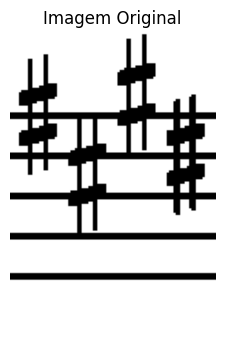

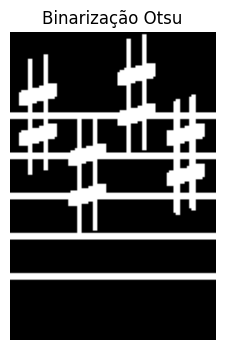

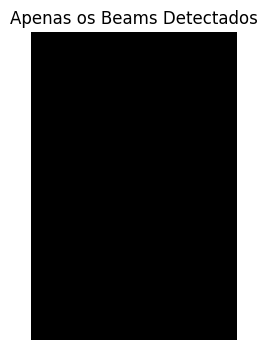

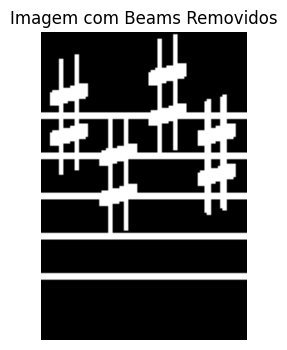

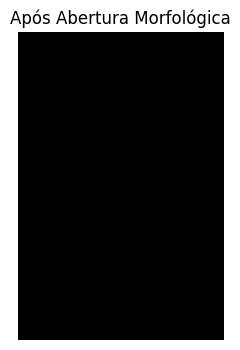

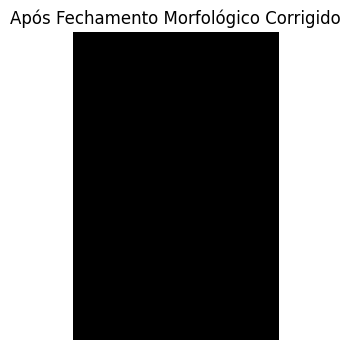

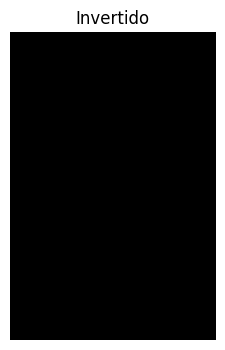

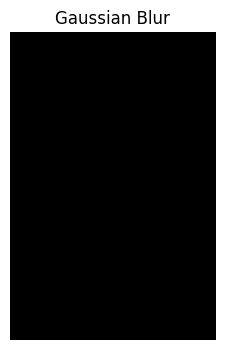

Nenhum círculo detectado


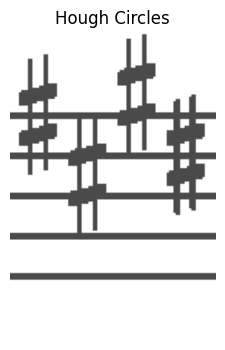

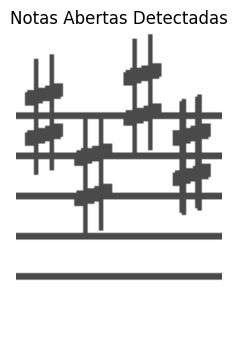

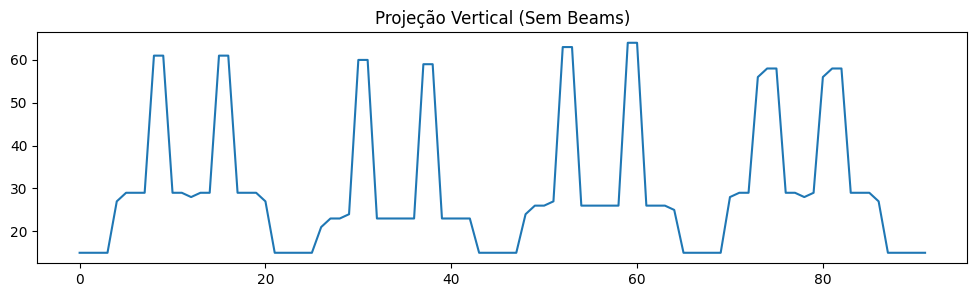

Cortes encontrados: []


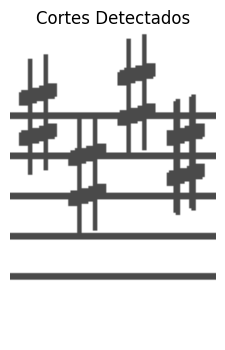

Símbolo dividido em 1 partes


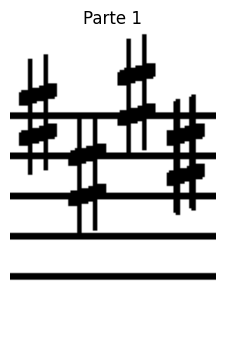

-> Segunda imagem sem cabeças detectadas: sem cortes.

Processando: simbolo_002.png (39x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_003.png (40x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_004.png (33x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_005.png (33x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_006.png (33x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_007.png (33x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_008.png (33x138px)
-> Símbolo menor que a largura base: sem cortes.

Processando: simbolo_009.png (200x138px)


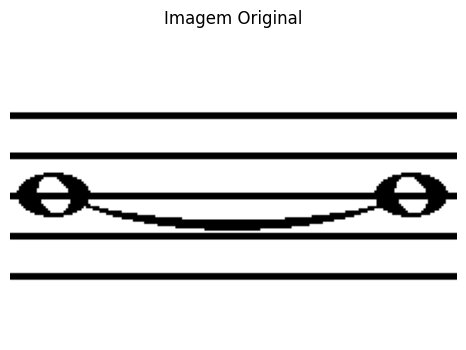

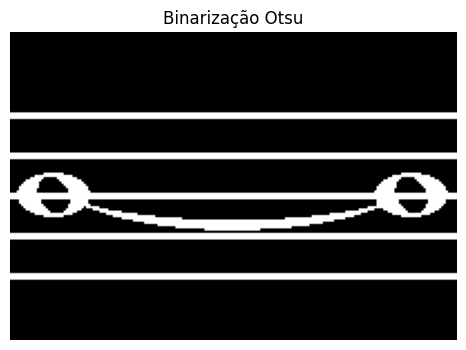

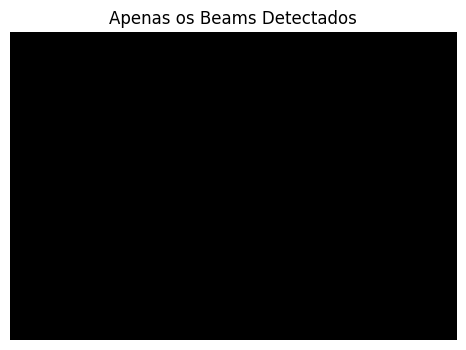

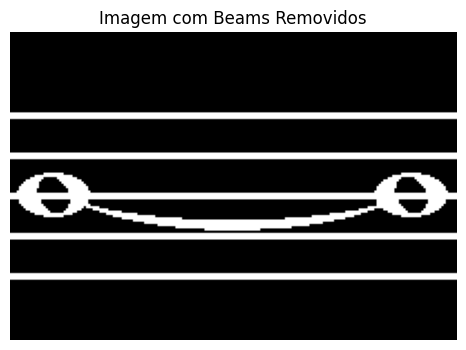

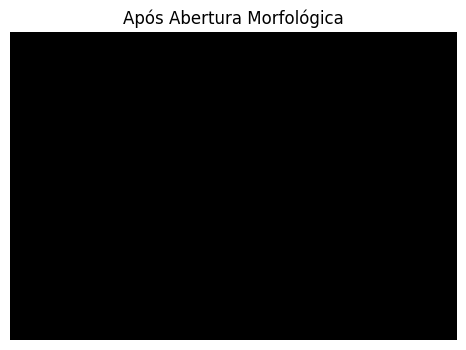

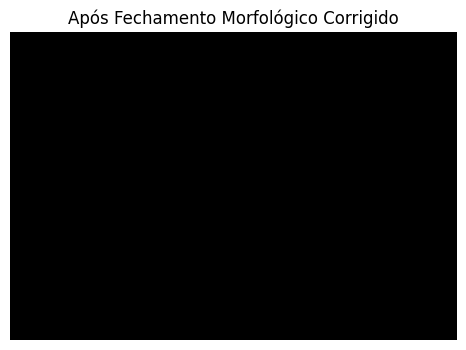

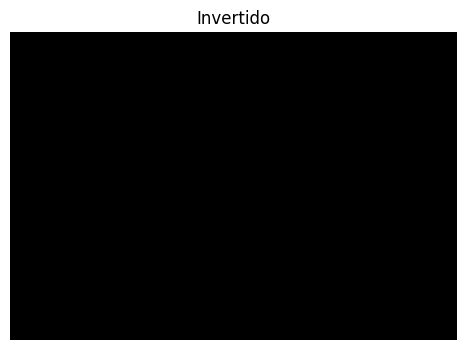

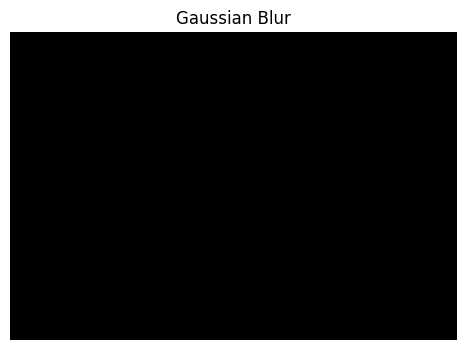

Nenhum círculo detectado


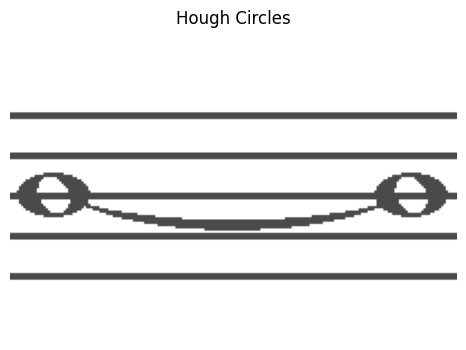

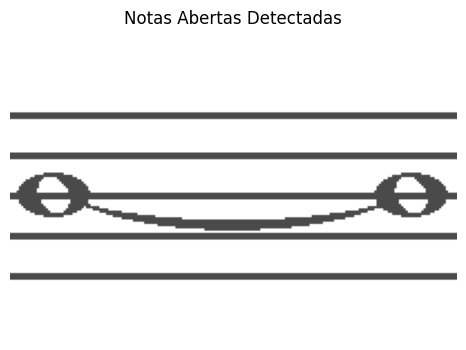

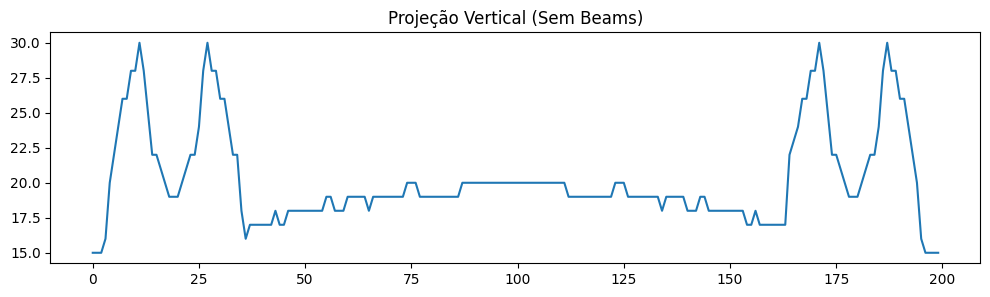

Cortes encontrados: []


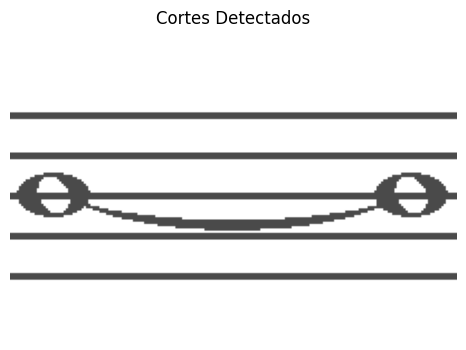

Símbolo dividido em 1 partes


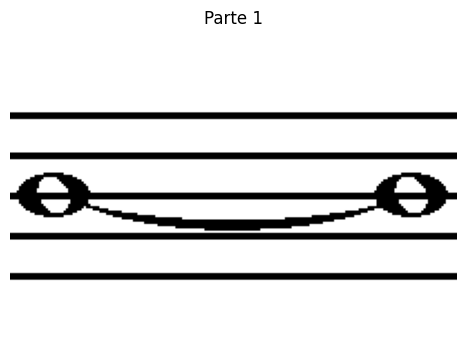


Sucesso!
-> 10 símbolos processados na pasta 'output_corrigido'.


In [105]:
# Executa o processamento apontando para as suas pastas locais
processar_pasta(
    pasta_entrada="output_simbolos",
    pasta_saida="output_corrigido",
    pasta_debug="output_debug",
    largura_base=63,
    dist_minima_cabecas=30
)